# Importing dependencies

In [1]:
# Dependencies
import numpy as np
import pandas as pd
import scipy.stats as stats

import normality_tests as nt

# Transforming the input data

In [2]:
# Location of files for the source frame and then location where to save the edited data
path_to_source = '../data/data_codon_changes_aggregated.csv'
path_to_final = '../data/codons-final.csv'
path_to_analysis_data = '../data/analysis_data.csv'

In [3]:
import data_transformation as dt

# First, we create a hash for all possible mutations according to the canonical genetic code
possible_mutations = dt.create_hash_mutations()

# Then we read the input data and add to the table the number of possible mutation pathways according to
# our mutation hash table, individually for each row (single nucleotide mutation that changes an amino acid)
data = dt.data_transformation(path_to_source, possible_mutations)
# We save this new table into our codons-final.csv file
data.to_csv(path_to_final, index=False)

# To be sure we didn't include any mistakes, we will run some checks on the dataset
dt.sanity_checks(data, possible_mutations)

# Furthermore, we will seperate a set of codons to look at in more detail, we are using it only in the plots
codons_of_interest = dt.seperate_interesting_codons(possible_mutations)

{'P': 1, 'A': 1, 'S': 1, 'K': 1, 'R': 1, 'I': 1}
{'P': 1, 'A': 1, 'S': 1, 'K': 1, 'R': 1, 'M': 1}
{'L': 1, 'V': 1, 'F': 1, 'N': 1, 'T': 1, 'S': 1, 'M': 1}
{'L': 1, 'V': 1, 'F': 1, 'N': 1, 'T': 1, 'S': 1, 'M': 1}
{'T': 1, 'A': 1, 'S': 1, 'Q': 1, 'R': 1, 'L': 1}
{'T': 1, 'A': 1, 'S': 1, 'H': 1, 'R': 1, 'L': 1}
{'T': 1, 'A': 1, 'S': 1, 'Q': 1, 'R': 1, 'L': 1}
{'T': 1, 'A': 1, 'S': 1, 'H': 1, 'R': 1, 'L': 1}
{'G': 1, 'Q': 1, 'P': 1, 'L': 1}
{'S': 1, 'G': 1, 'C': 1, 'H': 1, 'P': 1, 'L': 1}
{'G': 1, 'W': 1, 'Q': 1, 'P': 1, 'L': 1}
{'S': 1, 'G': 1, 'C': 1, 'H': 1, 'P': 1, 'L': 1}
{'I': 1, 'V': 1, 'Q': 1, 'P': 1, 'R': 1}
{'I': 1, 'V': 1, 'F': 1, 'H': 1, 'P': 1, 'R': 1}
{'M': 1, 'V': 1, 'Q': 1, 'P': 1, 'R': 1}
{'I': 1, 'V': 1, 'F': 1, 'H': 1, 'P': 1, 'R': 1}
{'T': 1, 'P': 1, 'S': 1, 'E': 1, 'G': 1, 'V': 1}
{'T': 1, 'P': 1, 'S': 1, 'D': 1, 'G': 1, 'V': 1}
{'T': 1, 'P': 1, 'S': 1, 'E': 1, 'G': 1, 'V': 1}
{'T': 1, 'P': 1, 'S': 1, 'D': 1, 'G': 1, 'V': 1}
{'S': 1, 'R': 1, 'C': 1, 'D': 1, 'A': 1, 'V'

### Statistics about the distribution of our data

In [4]:
print(len(data))
print(len(data[data["M. tuber"] == 0]))
print(len(data) - len(data[data["M. tuber"] == 0]))
print(len(data[data["M. tuber"] == 0]) / len(data))
print(len(data[data["M. tuber"] > 100]))
print(sum(data[data["M. tuber"] > 100]['M. tuber']))
print(sum(data['M. tuber']))

354
243
111
0.6864406779661016
11
3229
4413


In [5]:
sum_over_100 = sum(data[data["M. tuber"] > 100]['M. tuber'])
sum = sum(data['M. tuber'])
ratio = sum_over_100 / sum
print (f"The top 11 mutations, which were observed more than 100 times, represent {ratio:.3%} of all mutations.")

The top 11 mutations, which were observed more than 100 times, represent 73.170% of all mutations.


In [6]:
3229/4413

0.7317017901654204

# Visualizations

In [7]:
import graph_plotting as gr

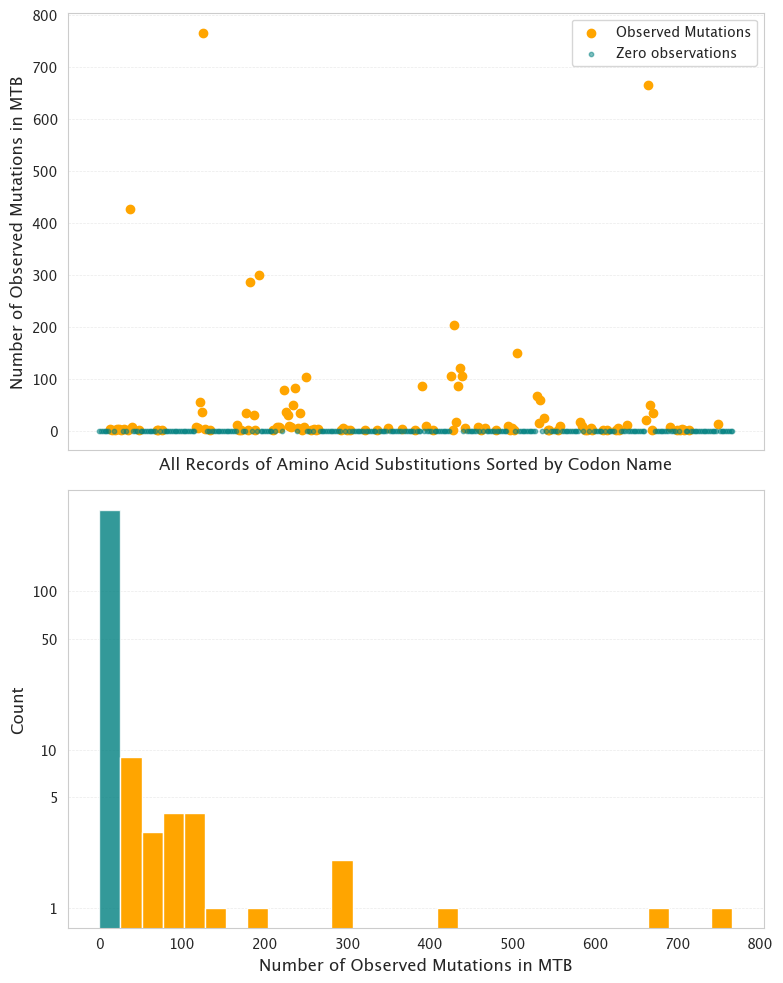

In [8]:
gr.combine_distribution_graph(data, False, True)

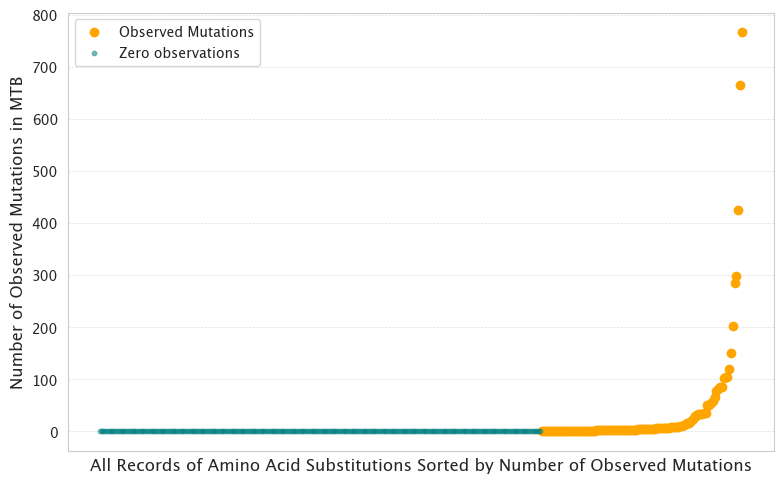

In [9]:
# Scatter plot of the data M. tuber
gr.scatterplot_observed(data, True)

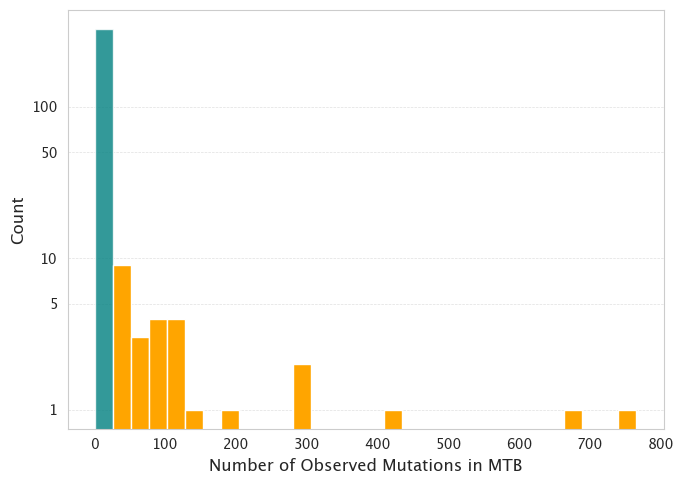

In [10]:
gr.histogram_all(data, True)

## Boxplot

/Users/barborajaskova/Documents/UK/bakalarka/code/graph_plotting.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = table['Mutation_Pathways'],


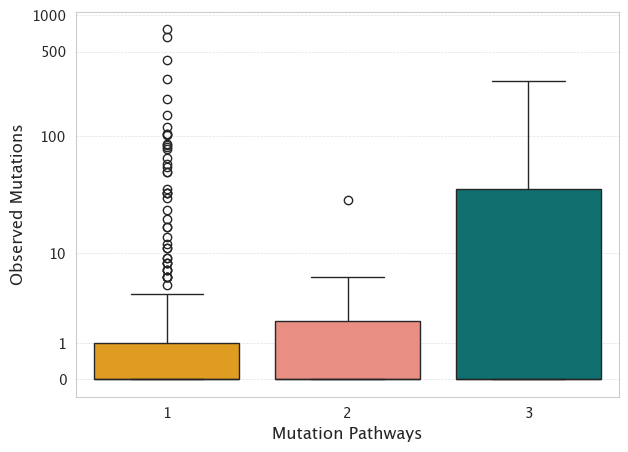

In [11]:
gr.boxplot(data, True)

### Is there a significant difference?

Let's check, if there is a significant difference between the observed numbers for 1, 2 or 3 possible mutation pathways.

We would like to use ANOVA, let's check the normality of the data.

In [12]:
for i in range (1, 4):
    nt.run(data[data["Mutation_Pathways"] == i], "M. tuber")

Normality Test Results

 M. tuber:
  - Shapiro-Wilk test: W = 0.1825, p-value = 4.934e-35
  - D'Agostino-Pearson test: K^2 = 515.2072, p-value = 1.331e-112

 The M. tuber data is NOT normally distributed (p < 0.05).


Normality Test Results

 M. tuber:
  - Shapiro-Wilk test: W = 0.3889, p-value = 9.74e-10
  - D'Agostino-Pearson test: K^2 = 61.1719, p-value = 5.208e-14

 The M. tuber data is NOT normally distributed (p < 0.05).


Normality Test Results

 M. tuber:
  - Shapiro-Wilk test: W = 0.6337, p-value = 0.001692
  - D'Agostino-Pearson test: K^2 = nan, p-value = nan

 The M. tuber data is NOT normally distributed (p < 0.05).




/Users/barborajaskova/Documents/UK/bakalarka/code/normality_tests.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  dagostino_test = normaltest(data[column_name])


It is not normally distributed, we have to use the non-parametric equivalent, which is Kruskal-Wallis Test

In [13]:
kruskal_stat, p_value = stats.kruskal(data[data["Mutation_Pathways"] == 1]["M. tuber"],
                               data[data["Mutation_Pathways"] == 2]["M. tuber"],
                               data[data["Mutation_Pathways"] == 3]["M. tuber"])

# Print results
print(f"Kruskal-Wallis statistic: {kruskal_stat:.4f}")
print(f"P-value: {p_value:.4g}")

#Interpretation
if p_value < 0.05:
    print("\nWe can reject the null hypothesis, therefore there is a significant difference between the groups.")
else:
    print("\nWe cannot reject the null hypothesis, that there is no significant difference between the groups.")

Kruskal-Wallis statistic: 1.6880
P-value: 0.43

We cannot reject the null hypothesis, that there is no significant difference between the groups.


### Barplots for each of interesting codons

In [14]:
# Plotting a histogram for each codon of interest
"""
for codon in codons_of_interest:
    print(f"Expected ratios of mutations for codon {codon}: {sorted(get_mutation_ratios(codon).items())}")
    gr.histogram_codon(data, codon)
"""

'\nfor codon in codons_of_interest:\n    print(f"Expected ratios of mutations for codon {codon}: {sorted(get_mutation_ratios(codon).items())}")\n    gr.histogram_codon(data, codon)\n'

In [15]:
len(codons_of_interest)

31

# Analysis

To further investigate the number of observed mutations, we can express the approximate by the following equation.
$$
\mathbb{E} [n(c, a)] \propto f(c)^{\beta _0} * \rho(c, a)^{\beta _1} * p_{acc}(c, a)^{\beta _2}
$$
where:
- $\mathbb{E} [n(c, a)]$ is the expected number of observed mutations that start with codon $c$ and result in mutated amino acid $a$
- $f(c)$ is the frequency of codon $c$ in the sample genome
- $\rho(c, a)$ is the number of mutation pathways that can lead from codon $c$ to amino acid $a$ according to the canonical genetic code
- $p_{acc}(c, a)$ is the probability of acceptance of this mutation in evolution
- $C$ is the constant for level of proportionality for this relationship
and
- $\beta _0, \beta _1, \beta _2$ are expressing the power of the dependance of the number of mutations on the individual factors

We would like to do a negative binomial regression, for which we need a sum and not a product -> We have to use logarithms.
$$
log(\mathbb{E} [n(c, a)]) = \alpha _0 + \beta _0log(f(c)) + \beta _1log(\rho(c, a)) + \beta _2log(p_{acc}(c, a))
$$

- $\alpha _0$ is the logarithm of the constant of proportionality $C$
However, we are not able to model the probability of acceptance due to its complexity, therefore we have to assume the probability is same for each of the changes and we will disregard this component $\beta _2log(p_{acc}(c, a))$.

Moreover, we assume that the number of observed mutations $n(c, a)$ is directly proportional to the frequency of codon $c$, $f(c)$. That means, we suppose that $\beta _0 = 1$. That way we can directly test the relationship between $n(c, a)$ and $\rho(c, a)$.

To sum up, we will be using this simplified version of the equation:
$$
log(\mathbb{E} [n(c, a)]) = \alpha _0 + log(f(c)) + \beta _1log(\rho(c, a))
$$

because we cannot fix the coefficient $\beta _0$ to 1, we have to adjust the formula beforehand, so the final formula we will be testing is:

$$
log(\frac{\mathbb{E} [n(c, a)]}{f(c)}) = \alpha _0 + \beta _1log(\rho(c, a))
$$

### Adding frequencies of codons from *Mycobacterium tuberculosis* into our table

In [16]:
# Extracting the codon frequencies for M. tuberculosis
path_to_frequencies = '../data/codon-frequencies.csv'

# I used this source: https://www.kazusa.or.jp/codon/cgi-bin/showcodon.cgi?species=83331
codon_frequencies = pd.read_csv(path_to_frequencies)
codon_frequencies['Codon'] = codon_frequencies['Codon'].str.replace('T', 'U')
codon_frequencies["CodonCount"] = codon_frequencies["CodonCount"].astype(int)
codon_frequencies["/1000"] = codon_frequencies["/1000"].astype(float)
codon_frequencies["Frequency"] = 100 * (codon_frequencies["CodonCount"] / codon_frequencies["CodonCount"].sum())

codon_frequencies.head()

# Merging the data with the codon frequencies
selected_columns = codon_frequencies[["Codon", "CodonCount", "Frequency"]]
data = data.merge(selected_columns, on='Codon', how='left')


### Creating the final data table for our analysis

In [17]:
data['LeftSide'] = data['M. tuber'] / data['Frequency']
data['LogPathways'] = np.log(data['Mutation_Pathways'])

data.to_csv(path_to_analysis_data, index=False)

In [18]:
#data = data.replace([np.inf, -np.inf], np.nan).dropna()

data

,Codon,Initiall_aa,Alt_aa,M. tuber,Mutation_Pathways,CodonCount,Frequency,LeftSide,LogPathways
0,AAA,K,E,0,1,7113,0.534425,0.0,0.000000
1,AAA,K,I,0,1,7113,0.534425,0.0,0.000000
2,AAA,K,N,0,2,7113,0.534425,0.0,0.693147
3,AAA,K,Q,0,1,7113,0.534425,0.0,0.000000
4,AAA,K,R,0,1,7113,0.534425,0.0,0.000000
...,...,...,...,...,...,...,...,...,...
349,UUU,F,I,0,1,8313,0.624585,0.0,0.000000
350,UUU,F,L,0,3,8313,0.624585,0.0,1.098612
351,UUU,F,S,0,1,8313,0.624585,0.0,0.000000
352,UUU,F,V,0,1,8313,0.624585,0.0,0.000000


### Normality and other checks

In [19]:
# Compute mean and variance of the count variable (M. tuber)
mean_m_tuber = data["M. tuber"].mean()
variance_m_tuber = data["M. tuber"].var()

mean_m_tuber, variance_m_tuber

print(f"Since the variance: {variance_m_tuber: 3f} is significantly larger than the mean: {mean_m_tuber: 3f}, \nthis confirms overdispersion, making Negative Binomial Regression the appropriate model \nrather than Poisson regression.")

Since the variance:  4228.056921 is significantly larger than the mean:  12.466102, 
this confirms overdispersion, making Negative Binomial Regression the appropriate model 
rather than Poisson regression.


In [20]:
for column in ['M. tuber', 'Mutation_Pathways', 'LeftSide']:
    nt.run(data, column)

Normality Test Results

 M. tuber:
  - Shapiro-Wilk test: W = 0.1863, p-value = 2.112e-36
  - D'Agostino-Pearson test: K^2 = 559.7707, p-value = 2.801e-122

 The M. tuber data is NOT normally distributed (p < 0.05).


Normality Test Results

 Mutation_Pathways:
  - Shapiro-Wilk test: W = 0.3312, p-value = 6.619e-34
  - D'Agostino-Pearson test: K^2 = 277.6421, p-value = 5.138e-61

 The Mutation_Pathways data is NOT normally distributed (p < 0.05).


Normality Test Results

 LeftSide:
  - Shapiro-Wilk test: W = 0.1485, p-value = 5.412e-37
  - D'Agostino-Pearson test: K^2 = 613.3425, p-value = 6.522e-134

 The LeftSide data is NOT normally distributed (p < 0.05).




### Another Kruskal-Wallis for normalised values

In [21]:
kruskal_stat, p_value = stats.kruskal(data[data["Mutation_Pathways"] == 1]["LeftSide"],
                               data[data["Mutation_Pathways"] == 2]["LeftSide"],
                               data[data["Mutation_Pathways"] == 3]["LeftSide"])

# Print results
print(f"Kruskal-Wallis statistic: {kruskal_stat:.3f}")
print(f"P-value: {p_value:.3g}")

#Interpretation
if p_value < 0.05:
    print("\nWe can reject the null hypothesis, therefore there is a significant difference between the groups.")
else:
    print("\nWe cannot reject the null hypothesis, that there is no significant difference between the groups.")

Kruskal-Wallis statistic: 1.928
P-value: 0.381

We cannot reject the null hypothesis, that there is no significant difference between the groups.


### Spearman's correlation test

In [22]:
# PERFORMING A SPEARMAN'S CORRELATION
spearman_corr, p_value = stats.spearmanr(data["LeftSide"], data["Mutation_Pathways"])

# Display results
print(f"Spearman correlation coefficient: {spearman_corr:.3f}")
print(f"P-value: {p_value:.3e}")

# Interpretation
if p_value < 0.05:
    print("We can reject H0 in favor of alternative hypothesis: There is a significant correlation.")
else:
    print("We fail to reject H0, which states that there is no significant correlation.")

Spearman correlation coefficient: 0.071
P-value: 1.824e-01
We fail to reject H0, which states that there is no significant correlation.


In [23]:
data.head()

,Codon,Initiall_aa,Alt_aa,M. tuber,Mutation_Pathways,CodonCount,Frequency,LeftSide,LogPathways
0,AAA,K,E,0,1,7113,0.534425,0.0,0.000000
1,AAA,K,I,0,1,7113,0.534425,0.0,0.000000
2,AAA,K,N,0,2,7113,0.534425,0.0,0.693147
3,AAA,K,Q,0,1,7113,0.534425,0.0,0.000000
4,AAA,K,R,0,1,7113,0.534425,0.0,0.000000


### Negative Binomial Regression
Just to bring to mind, we are testing this relationship:
$$
log(\frac{n(c, a)}{f(c)}) = \beta _0 + \beta _2log(\rho(c, a))
$$

In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the Negative Binomial regression model
model = smf.glm(
    formula = "LeftSide ~ LogPathways",
    data=data,
    family=sm.families.NegativeBinomial())

# Fit the model
result = model.fit()

# Display the summary of the regression
result.summary()

/Users/barborajaskova/Documents/UK/bakalarka/code/.venv/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               LeftSide   No. Observations:                  354
Model:                            GLM   Df Residuals:                      352
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1035.7
Date:                Tue, 08 Apr 2025   Deviance:                       1522.4
Time:                        14:11:50   Pearson chi2:                 1.15e+04
No. Iterations:                    11   Pseudo R-squ. (CS):           0.008057
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.8260      0.060     30.420      0.000       1.708       1.944
LogPathways     0.3529      0.252      1.402      0.161      -0.141       0.846
===============================================================================
"""

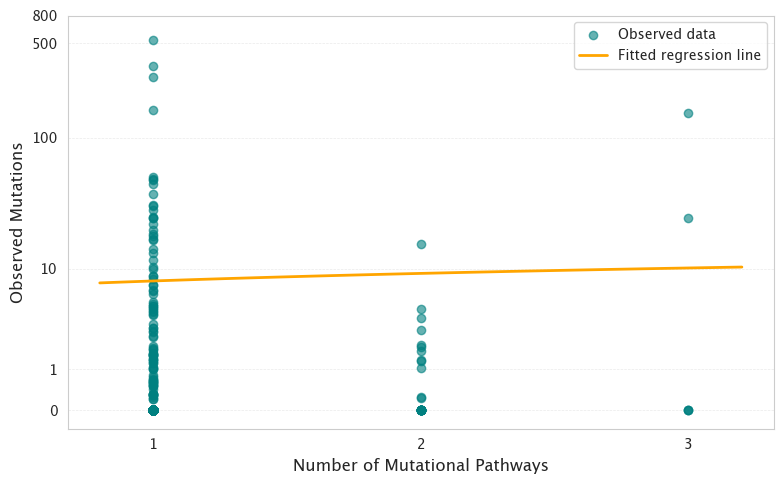

In [25]:
x_vals_raw = np.linspace(0.8, 3.2, 100)
x_vals_log = np.log1p(x_vals_raw)
y_pred = result.predict(pd.DataFrame({"LogPathways": x_vals_log}))
y_pred_log = np.log1p(y_pred)

gr.plot_regression(data, x_vals_raw, y_pred_log)

## Boxplot with observed counts divided by frequencies

/Users/barborajaskova/Documents/UK/bakalarka/code/graph_plotting.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = table['Mutation_Pathways'],


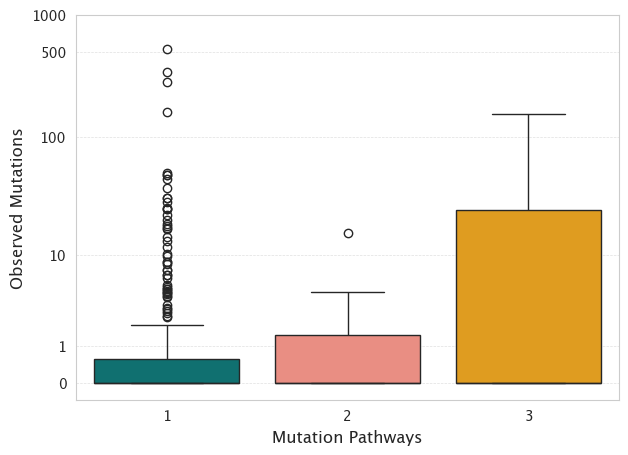

In [26]:
gr.boxplot_freq(data, True)

In [27]:
sorted(dt.get_mutation_ratios(possible_mutations, "AUG").items())

[('I', 3), ('K', 1), ('L', 2), ('R', 1), ('T', 1), ('V', 1)]

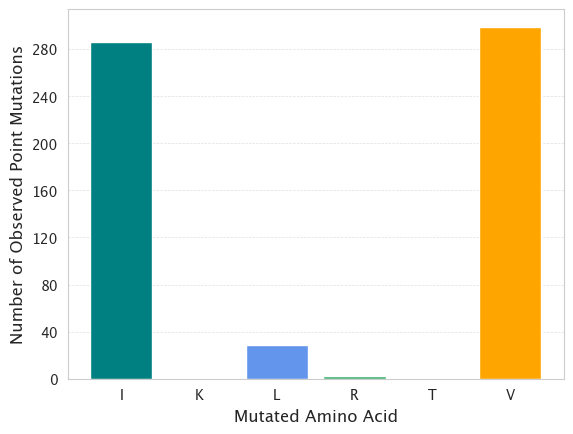

In [28]:
gr.histogram_codon(data, "AUG")


In [29]:
from matplotlib.colors import to_hex

to_hex("cornflowerblue")


'#6495ed'